### Quantifying Fossil Abundance
In this notebook, we work to quantify the abundance of fossils (%) in thin sections using our trained model. We will try random patching, classifying with the trained model, and compare our results to the hand counted abundance data. 

In [1]:

# Import dependencies
import numpy as np 
import keras
from keras import layers
import tensorflow_datasets as tfds
from tensorflow import data as tf_data
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
from skimage import io
import pandas as pd
import gc
print(tf.config.list_physical_devices("GPU"))

image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
def CreatePatches(image, patch_size, num_patches, overlap, method = 'random', mirror_edges = True):
    '''
    This function takes in a resized thin section image and returns a collection of image patches for thin section sorting. 
    Inputs: 
        - image: The thin section image to patch. 
        - patch_size: This should be a pixel size for patches. Patches are assumed to be square, so input will be the width/length of square patches. 
        - num_patches: Only relevant if method = 'random'. This will give the number of randomly generated patches to create from the image. 
        - overlap: This specifies the number of pixels to overlap between each patch on the grid or the allowed overlap in random patches.
        - method: Options are 'random' and 'grid'. 'random' will generate a random number of patches according to num_patches. 'grid' will generate patches on a grid. 
        - mirror_edges: Optional mirroring of the edges. This helps deal with edges of thin sections. In this case, edges are mirrored and patches are only allowed to be generated up to the original edge of the image.
        mirror_edges will only pad out to the last pixel that we could get using patch_size.
    Outputs:
        - patches: The collection of thin section patches according to user specifications.
        - coordinates: The coordinates of each generated patch on the image.
    '''
    patches = []
    img_array = np.asarray(image)
    if mirror_edges == True:
        img_array = np.pad(img_array, pad_width=((patch_size, patch_size), (patch_size, patch_size), (0, 0)), mode='reflect')
    if method == 'random':
        coordinates = np.zeros((num_patches, 2))
        if mirror_edges:
            y_max = img_array.shape[1] - patch_size
            y_min = patch_size
            x_max = img_array.shape[0] - patch_size
            x_min = patch_size
        if not mirror_edges:
            y_max = img_array.shape[1]
            y_min = 0
            x_max = img_array.shape[0]
            x_min = 0
        for i in range(num_patches):
            # Randomly generate coordinates
            x = np.random.randint(x_min, x_max)
            y = np.random.randint(y_min, y_max)

            # Save coordinates of random patch
            if mirror_edges:
                coordinates[i, 0] = x - patch_size
                coordinates[i, 1] = y - patch_size 
            if not mirror_edges:
                coordinates[i, 0] = x
                coordinates[i, 1] = y

            random_patch = img_array[x:x + patch_size, y:y + patch_size]
            patches.append(random_patch)
    if method == 'grid':
        step_size = patch_size - overlap
        if mirror_edges:
            height, width = img_array.shape[0] - patch_size, img_array.shape[1] - patch_size
            x_min = patch_size
            y_min = patch_size
        if not mirror_edges:
            height, width = img_array.shape[0], img_array.shape[1]
            x_min = 0
            y_min = 0 
        patches = []
        coordinates = []
        for x in range(patch_size, height - patch_size + 1, step_size):
            for y in range(patch_size, width - patch_size + 1, step_size):
                grid_patch = img_array[x:x + patch_size, y:y + patch_size]
                patches.append(grid_patch)
                coordinates.append((x,y))
        coordinates = np.asarray(coordinates)
    if method != 'grid' and method != 'random':
        print("Please select a valid method")
        return None, None
    return patches, coordinates

import os
from skimage import io

def SavePatches(patches, folder, prefix="patch"):
    os.makedirs(folder, exist_ok=True)
    for i, patch in enumerate(patches):
        io.imsave(os.path.join(folder, f"{prefix}_{i:05d}.png"),
                  np.asarray(patch).astype(np.uint8), check_contrast=False)

def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.7)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomContrast(0.2)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

def GetRandomThinSections(samplelist, num_sections):
    if samplelist.empty:
        print("No rows found in sample list")
        return []

    n = min(num_sections, len(samplelist))

    return (
        samplelist.iloc[:, 0]   # first (only) column, no header name needed
        .astype(str)
        .str.strip()
        .sample(n=n)
        .tolist()
    )


2026-09-29 15:47:14.333665: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-09-29 15:47:14.333692: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-29 15:47:14.333698: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1790722034.333713  771893 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790722034.333764  771893 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
print(np.random.randint(0, 100, 10))

[64 60  1 79 50 61  1 91 90 52]


Sections Isolated for Testing:
['ope_50.0', 'opd_19.0', 'opf_73.0', 'opf_97.0', 'opd_64.0', 'ope_70.0', 'opb_48.4', 'opd_59.0', 'opc_18.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opb_48.4_patch4.png'
 '../../Data/Center_Fossil/resized_opc_18.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opc_18.0d_patch3.png'
 '../../Data/Center_Fossil/resized_opd_19.0a_patch4.png'
 '../../Data/Center_Fossil/resized_opd_19.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch2.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch5.png'
 '../../Data/Center_Fossil/resized_opd_59.0b_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0c_patch2.png'
 '../../Data/Center_Fossil/resized_opd_64.0a_patch2.png'
 '../../Data/Center_Fossil/resized_opd_64.0a_patch4.png'
 '../../Data/Center_Fossil/resized_opd_64.0b_patch2.png'
 '../../Data/Cen

2026-09-29 15:47:15.337109: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-09-29 15:47:15.897327: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


train: 544 samples (453 pos, 91 neg), class_weight={0: 2.989010989010989, 1: 0.6004415011037527}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_1     │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation_1 │ (None, 200,     │         0 │ random_flip_1… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 484ms/step - auc: 0.8915 - binary_accuracy: 0.7785 - loss: 0.6610 - precision_1: 0.9224 - recall_1: 0.6556 - specificity_at_sensitivity_1: 0.5989 - val_auc: 0.9054 - val_binary_accuracy: 0.7797 - val_loss: 0.6716 - val_precision_1: 0.9675 - val_recall_1: 0.7602 - val_specificity_at_sensitivity_1: 0.7000
Epoch 2/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 365ms/step - auc: 0.8685 - binary_accuracy: 0.7723 - loss: 0.8150 - precision_1: 0.9133 - recall_1: 0.6512 - specificity_at_sensitivity_1: 0.0000e+00 - val_auc: 0.8960 - val_binary_accuracy: 0.7458 - val_loss: 0.8532 - val_precision_1: 0.9595 - val_recall_1: 0.7245 - val_specificity_at_sensitivity_1: 0.7000
Epoch 3/8
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 363ms/step - auc: 0.9076 - binary_accuracy: 0.8091 - loss: 0.6370 - precision_1: 0.9407 - recall_1: 0.6998 - specificity_at_sensitivity_1: 0.7335 - val_auc: 0.9012 - val_binary_accuracy: 0.7542 - val_loss: 1.0126 - val_precision_1: 0.9859

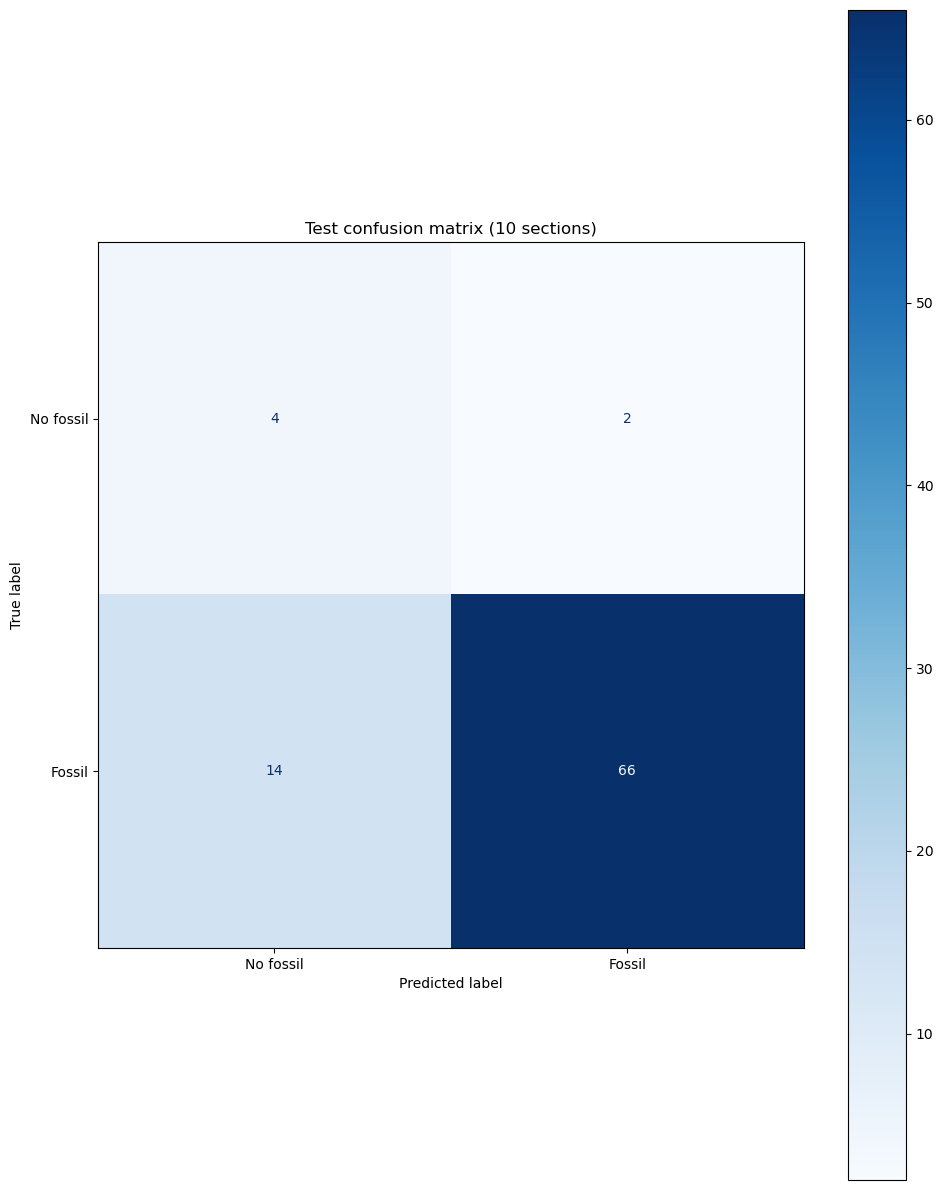

In [ ]:
sections = ['ope_50.0', 'opd_19.0', 'opf_73.0', 'opf_97.0', 'opd_64.0','ope_70.0', 'opb_48.4', 'opd_59.0', 'opc_18.0']
print(f"Sections Isolated for Testing:")
print(sections)

train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(no_center_fossil_folder, sections)
train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

# Transform numpy arrays to tf datasets

training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

# Shuffle data
training_data = training_data.shuffle(len(Y_train))
#validation_data = validation_data.shuffle(len(Y_val))
#testing_data = testing_data.shuffle(len(Y_test))
    
# Augment Data
training_data = training_data.map(
lambda x, y: (tf.cast(x, tf.float32), y)
)

nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil3 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
#augfossil4 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    


training_data = training_data.concatenate(augfossil)
training_data = training_data.concatenate(augfossil2)
training_data = training_data.concatenate(augfossil3)
#training_data = training_data.concatenate(augfossil4)

n_pos = int(Y_train.sum())
n_neg = len(Y_train) - n_pos

training_data = training_data.shuffle(2*n_pos + 4*n_neg)
    
n_train = sum(1 for _ in training_data)
training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
# Batch and prefetch data 

batch_size = 32 # this could change

training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

n_pos = int(Y_train.sum())
n_neg = len(Y_train) - n_pos
class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

THRESH = 0.55   # change this to whatever cutoff you want
# Create the base model with the pre-trained imagenet weights
base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
x = layers.RandomFlip("horizontal_and_vertical")(inputs)
x = layers.RandomRotation(1.0, fill_mode="reflect")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    #x = layers.AutoContrast(value_range = (0, 255))(x)
x = base_model(x, training=False)                         # (batch, 7, 7, 2048)
    # Combine average pooling (overall context) with max pooling (strongest local response)
avg_pool = layers.GlobalAveragePooling2D()(x)             # (batch, 2048)
max_pool = layers.GlobalMaxPooling2D()(x)                 # (batch, 2048)
x = layers.Concatenate()([avg_pool, max_pool])            # (batch, 4096)

x = layers.Dropout(0.1)(x)
x = layers.Dense(128, activation="relu")(x)               # hidden layer
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    #x = layers.GlobalAveragePooling2D()(x)

   # x = layers.Dropout(0.1)(x)
    #outputs = layers.Dense(1, activation="sigmoid")(x)
    #model = keras.Model(inputs, outputs)

model.summary(show_trainable = True)

    # Train the new top layer of the model
model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

epochs = 20 # also play with this
print(f"Fitting top layer of model")
early_stop = keras.callbacks.EarlyStopping(
            monitor = "val_auc", mode = "max", patience = 10, restore_best_weights = True)
    
history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight, callbacks = [early_stop])

    # Fine tune entire model
    # Fine tune (gently)
base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

model.summary(show_trainable=True)   # now shows the real trainable state

model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 5, restore_best_weights = True)

epochs = 8 #??
print(f"Fitting end-to-end model")
history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
print(f"Test dataset evaluation:")
test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
y_prob = model.predict(testing_data).ravel()
y_pred = (y_prob >= THRESH).astype(int)
y_true = Y_test.astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix ({10} test sections):")
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

fig, ax = plt.subplots(figsize=(10, 12))
ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Test confusion matrix ({10} sections)")
plt.tight_layout()
plt.show()


Generate patches for each image. 

(1646, 2895, 4) uint8


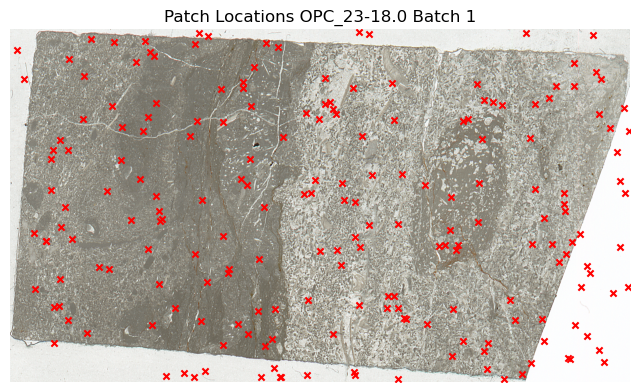

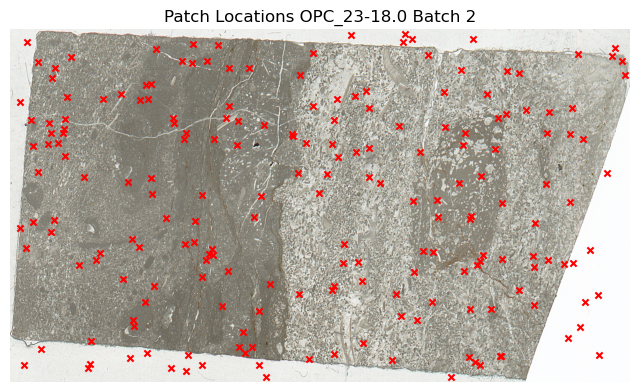

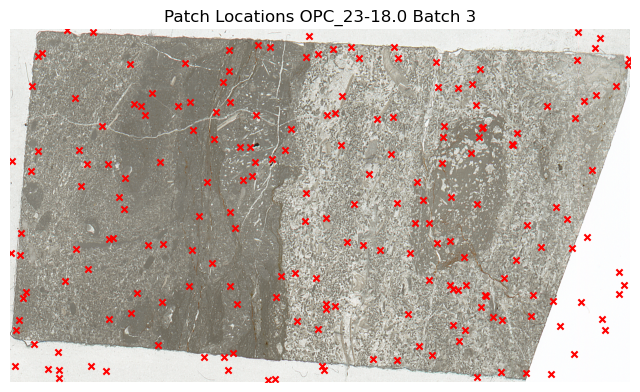

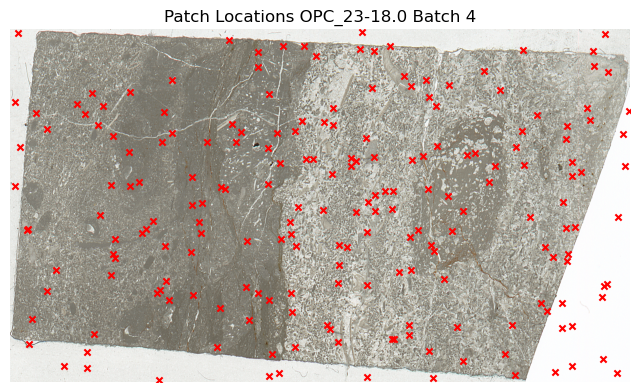

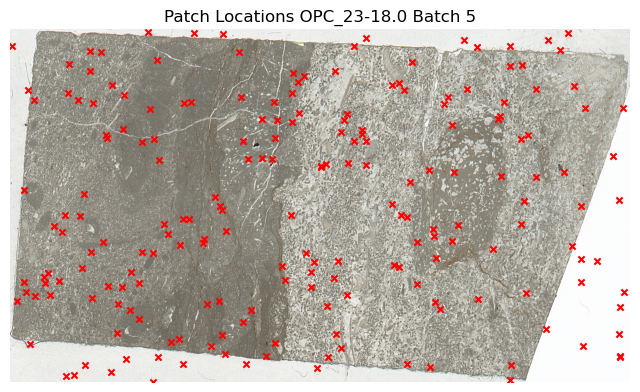

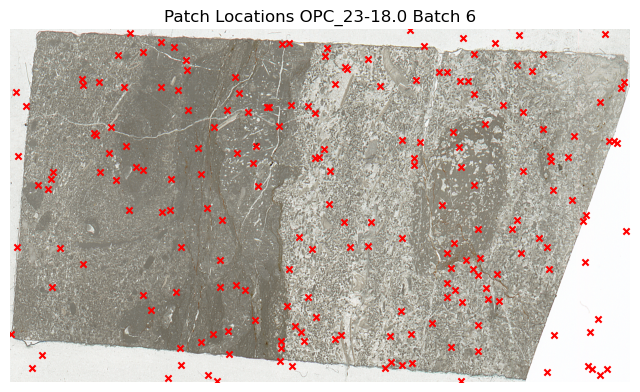

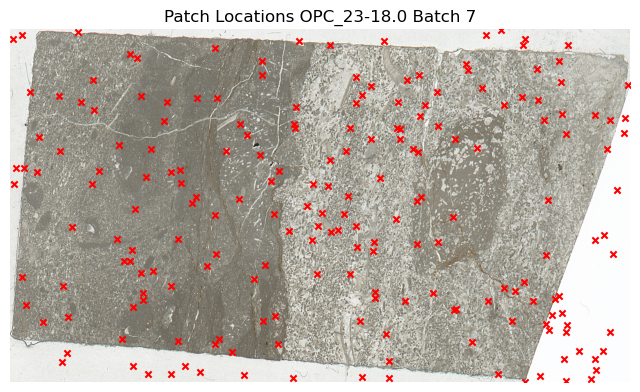

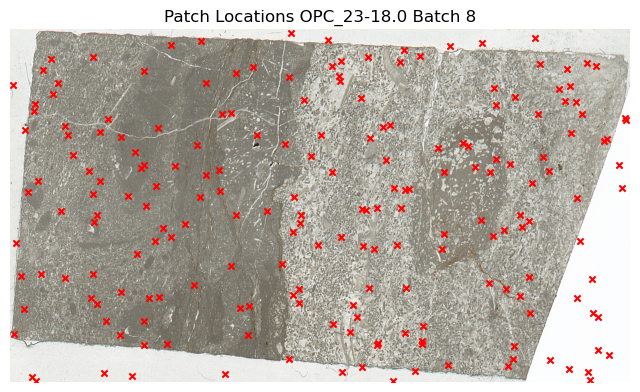

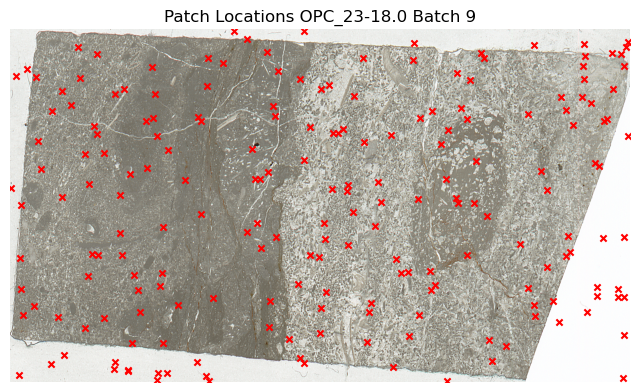

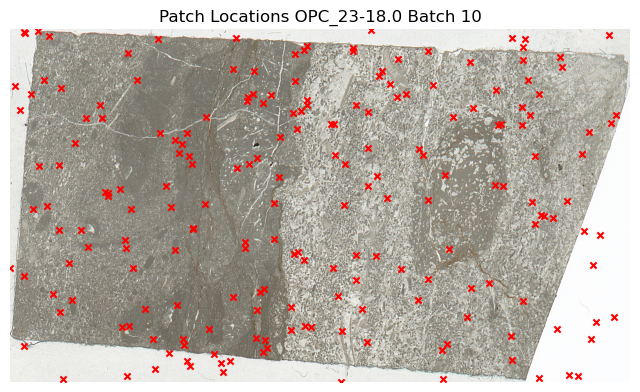

In [14]:
image = io.imread("../../Data/FossilAbundance/OPC_23-18.0.tif")
print(image.shape, image.dtype)   # check this before patching
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 1')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch1", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 2')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch2", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 3')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch3", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 4')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch4", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 5')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch5", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 6')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch6", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 7')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch7", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 8')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch8", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 9')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch9", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.scatter(coords[:, 1], coords[:, 0], c='red', s=20, marker='x')
plt.title('Patch Locations OPC_23-18.0 Batch 10')
plt.axis('off')
plt.show()
SavePatches(patches, "../../Data/FossilAbundance/OPC18Batch10", prefix="patch")


Now, I want to predict on these patches. 

In [6]:
def LoadPatchesFromFolder(folder, patch_size=200):
    names = sorted(f for f in os.listdir(folder)
                   if f.lower().endswith((".png", ".jpg", ".jpeg")))
    patches, kept = [], []
    for f in names:
        img = io.imread(os.path.join(folder, f))
        if img.ndim == 2:                      # grayscale -> 3 channels
            img = np.stack([img] * 3, axis=-1)
        img = img[..., :3]                     # drop alpha if present
        if img.shape[:2] != (patch_size, patch_size):
            print(f"Skipping {f}: shape {img.shape}")
            continue
        patches.append(img)
        kept.append(f)
    return np.stack(patches).astype("float32"), kept
percentages = []
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch1")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch2")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch3")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch4")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch5")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch6")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch7")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch8")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch9")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPC18Batch10")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")

print(f'Average Fossil Content: {np.mean(percentages)}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step
Fossil: 69  No fossil: 131  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 74  No fossil: 126  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 65  No fossil: 135  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 79  No fossil: 121  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 85  No fossil: 115  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 98  No fossil: 102  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step 
Fossil: 74  No fossil: 126  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step 
Fossil: 89  No fossil: 111  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step 
Fossil: 81  No fossil: 119  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step 
Fossil: 74  No fossil: 126  (total 200)
Average Fossil Content: 0.394


In [7]:
image = io.imread("../../Data/FossilAbundance/OPD_23-59.0.tif")
print(image.shape, image.dtype)   # check this before patching
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch1", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch2", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch3", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch4", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch5", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch6", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch7", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch8", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch9", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPD59Batch10", prefix="patch")

(3198, 3405, 4) uint8


In [9]:
percentages = []
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch1")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch2")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch3")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch4")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch5")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch6")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch7")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch8")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch9")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPD59Batch10")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
print(f'Average Fossil Content: {np.mean(percentages)}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step 
Fossil: 95  No fossil: 105  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 95  No fossil: 105  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 92  No fossil: 108  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 84  No fossil: 116  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 93  No fossil: 107  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 91  No fossil: 109  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
Fossil: 98  No fossil: 102  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 86  No fossil: 114  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 102  No fossil: 98  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 97  No fossil: 103  (total 200)
Average Fossil Content: 0.4665


In [10]:
image = io.imread("../../Data/FossilAbundance/OPE_23-50.0.tif")
print(image.shape, image.dtype)   # check this before patching
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch1", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch2", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch3", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch4", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch5", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch6", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch7", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch8", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch9", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE50Batch10", prefix="patch")

(2731, 3716, 4) uint8


In [11]:
percentages = []
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch1")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch2")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch3")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch4")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch5")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch6")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch7")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch8")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch9")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE50Batch10")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
print(f'Average Fossil Content: {np.mean(percentages)}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step
Fossil: 60  No fossil: 140  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
Fossil: 63  No fossil: 137  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 60  No fossil: 140  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 68  No fossil: 132  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 63  No fossil: 137  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 53  No fossil: 147  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 56  No fossil: 144  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 71  No fossil: 129  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 61  No fossil: 139  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 74  No fossil: 126  (total 200)
Average Fossil Content: 0.3145


In [12]:
image = io.imread("../../Data/FossilAbundance/OPE_23-70.0.tif")
print(image.shape, image.dtype)   # check this before patching
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch1", prefix="patch")

patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch2", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch3", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch4", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch5", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch6", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch7", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch8", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch9", prefix="patch")
patches, coords = CreatePatches(image, 200, 200, 0, method = 'random', mirror_edges = True)
SavePatches(patches, "../../Data/FossilAbundance/OPE70Batch10", prefix="patch")

(1850, 3445, 4) uint8


In [13]:
percentages = []
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch1")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch2")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch3")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch4")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch5")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch6")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch7")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch8")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch9")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
X, names = LoadPatchesFromFolder("../../Data/FossilAbundance/OPE70Batch10")

probs = model.predict(X, batch_size=32).ravel()
is_fossil = probs >= THRESH
percentages.append(is_fossil.sum()/200)

print(f"Fossil: {is_fossil.sum()}  No fossil: {(~is_fossil).sum()}  (total {len(probs)})")
print(f'Average Fossil Content: {np.mean(percentages)}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
Fossil: 72  No fossil: 128  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 59  No fossil: 141  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 59  No fossil: 141  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 69  No fossil: 131  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 55  No fossil: 145  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Fossil: 73  No fossil: 127  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 67  No fossil: 133  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 60  No fossil: 140  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step 
Fossil: 66  No fossil: 134  (total 200)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fossil: 65  No fossil: 135  (total 200)
Average Fossil Content: 0.3225
